In [36]:
from google.colab import files
uploaded = files.upload()

Saving GenAI_Media_Perf_2026.csv.csv to GenAI_Media_Perf_2026.csv (2).csv


In [37]:
import pandas as pd
import numpy as np

df = pd.read_csv("GenAI_Media_Perf_2026.csv.csv")
df.head()

,content_id,platform,content_type,ai_tool_used,ai_type,duration_seconds,production_cost_usd,views,likes,comments,shares,engagement_rate,watch_time_avg_sec,retention_rate,revenue_usd
0,ACC000001,TikTok,Short,Adobe Firefly,Text-to-video,20,15.93,10529,474,52,39,0.0537,7.30,42.04,9.95
1,ACC000002,TikTok,Short,HeyGen,Avatar video,12,23.21,10058,451,64,44,0.0556,5.99,54.76,5.70
2,ACC000003,YouTube,Short,Canva AI,AI-assisted editing,46,14.60,4349,187,23,10,0.0506,34.01,85.35,2.98
3,ACC000004,TikTok,Reel,InVideo AI,AI-assisted editing,27,10.07,23968,1259,140,236,0.0682,19.54,73.52,4.62
4,ACC000005,TikTok,Short,Pika,Text-to-video,52,16.85,3290,118,22,35,0.0532,25.67,53.88,0.61


In [38]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.isnull().sum())

(30000, 15)
Index(['content_id', 'platform', 'content_type', 'ai_tool_used', 'ai_type',
       'duration_seconds', 'production_cost_usd', 'views', 'likes', 'comments',
       'shares', 'engagement_rate', 'watch_time_avg_sec', 'retention_rate',
       'revenue_usd'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   content_id           30000 non-null  object 
 1   platform             30000 non-null  object 
 2   content_type         30000 non-null  object 
 3   ai_tool_used         30000 non-null  object 
 4   ai_type              30000 non-null  object 
 5   duration_seconds     30000 non-null  int64  
 6   production_cost_usd  30000 non-null  float64
 7   views                30000 non-null  int64  
 8   likes                30000 non-null  int64  
 9   comments             30000 non-null  int64  
 1

# **CLEANING**

In [39]:
df = df.drop("content_id", axis=1)
df = df.drop_duplicates()

In [40]:
def remove_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = np.where(df[col] > upper, upper,
                    np.where(df[col] < lower, lower, df[col]))
    return df

num_cols = df.select_dtypes(include=['int64','float64']).columns
df = remove_outliers(df, num_cols)


In [41]:
print("\nFinal Shape:", df.shape)
print(df.head())
print("\nMissing Values:\n", df.isnull().sum())


Final Shape: (30000, 14)
  platform content_type   ai_tool_used              ai_type  duration_seconds  \
0   TikTok        Short  Adobe Firefly        Text-to-video              20.0   
1   TikTok        Short         HeyGen         Avatar video              12.0   
2  YouTube        Short       Canva AI  AI-assisted editing              46.0   
3   TikTok         Reel     InVideo AI  AI-assisted editing              27.0   
4   TikTok        Short           Pika        Text-to-video              52.0   

   production_cost_usd    views   likes  comments  shares  engagement_rate  \
0                15.93  10529.0   474.0      52.0    39.0           0.0537   
1                23.21  10058.0   451.0      64.0    44.0           0.0556   
2                14.60   4349.0   187.0      23.0    10.0           0.0506   
3                10.07  23968.0  1259.0     140.0   230.5           0.0682   
4                16.85   3290.0   118.0      22.0    35.0           0.0532   

   watch_time_avg_

In [42]:
print(df.head())
print(df.info())
print(df.describe())

  platform content_type   ai_tool_used              ai_type  duration_seconds  \
0   TikTok        Short  Adobe Firefly        Text-to-video              20.0   
1   TikTok        Short         HeyGen         Avatar video              12.0   
2  YouTube        Short       Canva AI  AI-assisted editing              46.0   
3   TikTok         Reel     InVideo AI  AI-assisted editing              27.0   
4   TikTok        Short           Pika        Text-to-video              52.0   

   production_cost_usd    views   likes  comments  shares  engagement_rate  \
0                15.93  10529.0   474.0      52.0    39.0           0.0537   
1                23.21  10058.0   451.0      64.0    44.0           0.0556   
2                14.60   4349.0   187.0      23.0    10.0           0.0506   
3                10.07  23968.0  1259.0     140.0   230.5           0.0682   
4                16.85   3290.0   118.0      22.0    35.0           0.0532   

   watch_time_avg_sec  retention_rate  reven

In [43]:
df.head()

,platform,content_type,ai_tool_used,ai_type,duration_seconds,production_cost_usd,views,likes,comments,shares,engagement_rate,watch_time_avg_sec,retention_rate,revenue_usd
0,TikTok,Short,Adobe Firefly,Text-to-video,20.0,15.93,10529.0,474.0,52.0,39.0,0.0537,7.30,42.04,9.95
1,TikTok,Short,HeyGen,Avatar video,12.0,23.21,10058.0,451.0,64.0,44.0,0.0556,5.99,54.76,5.70
2,YouTube,Short,Canva AI,AI-assisted editing,46.0,14.60,4349.0,187.0,23.0,10.0,0.0506,34.01,85.35,2.98
3,TikTok,Reel,InVideo AI,AI-assisted editing,27.0,10.07,23968.0,1259.0,140.0,230.5,0.0682,19.54,73.52,4.62
4,TikTok,Short,Pika,Text-to-video,52.0,16.85,3290.0,118.0,22.0,35.0,0.0532,25.67,53.88,0.61


### **EDA**



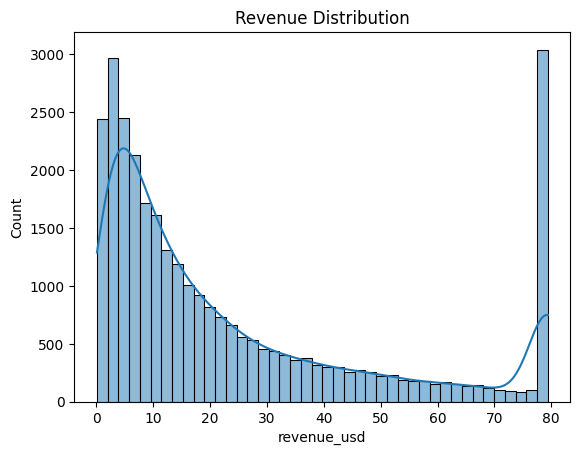

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

#TARGET DISTRIBUTION
plt.figure()
sns.histplot(df['revenue_usd'], kde=True)
plt.title("Revenue Distribution")
plt.show()

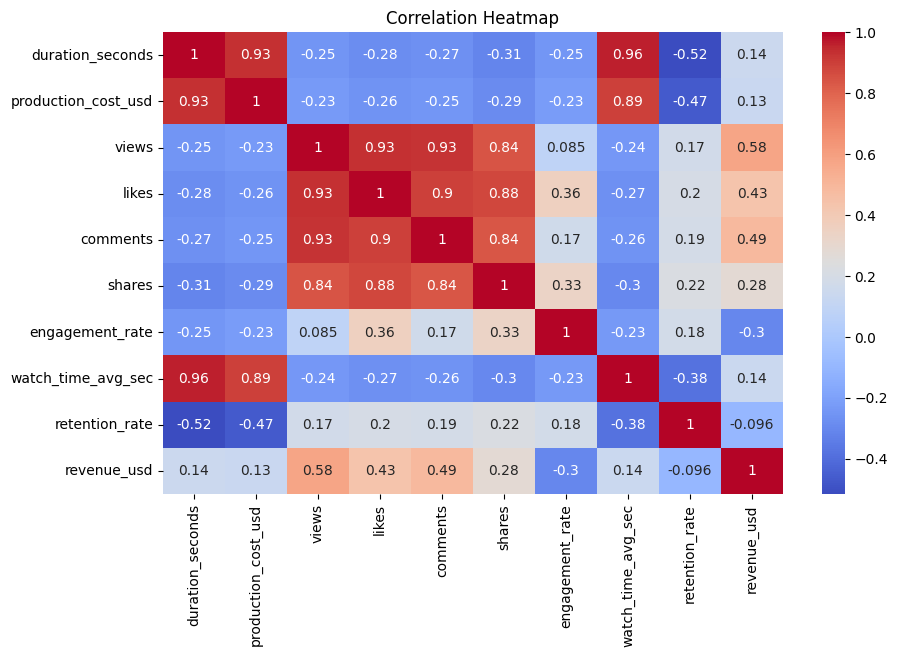

In [45]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

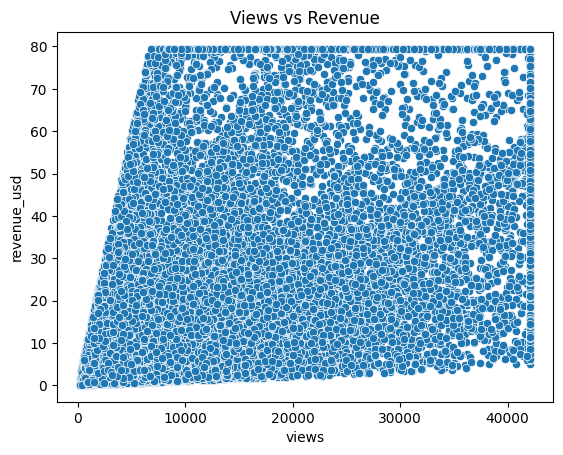

In [46]:
# Views vs Revenue
plt.figure()
sns.scatterplot(x='views', y='revenue_usd', data=df)
plt.title("Views vs Revenue")
plt.show()


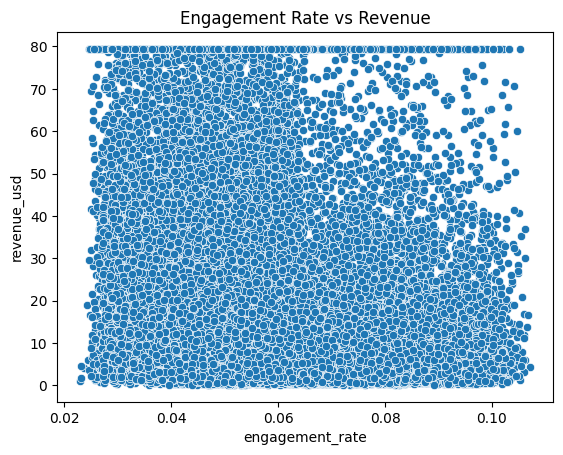

In [47]:
# Engagement vs Revenue
plt.figure()
sns.scatterplot(x='engagement_rate', y='revenue_usd', data=df)
plt.title("Engagement Rate vs Revenue")
plt.show()

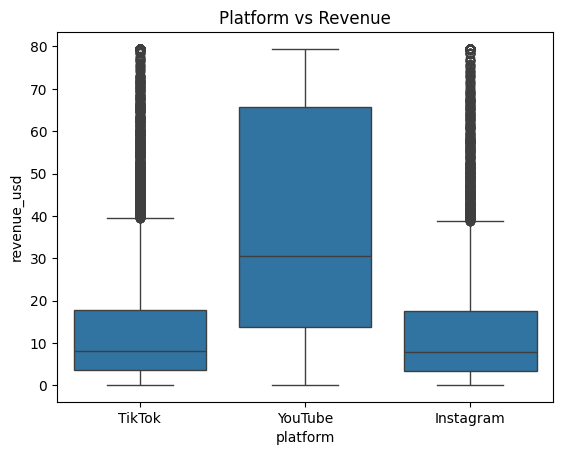

In [48]:
# Platform comparison
plt.figure()

sns.boxplot(x='platform', y='revenue_usd', data=df)
plt.title("Platform vs Revenue")
plt.show()

## **FEATURE ENGINEERING**

### 1. BASIC RATIO FEATURES

In [49]:
df['engagement_score'] = (df['likes'] + df['comments'] + df['shares']) / df['views']
df['roi'] = df['revenue_usd'] / df['production_cost_usd']
df['views_per_sec'] = df['views'] / df['duration_seconds']

### 2. NORMALIZED ENGAGEMENT FEATURES

In [50]:
df['likes_ratio'] = df['likes'] / df['views']
df['comments_ratio'] = df['comments'] / df['views']
df['shares_ratio'] = df['shares'] / df['views']

### 3. COST & PROFIT FEATURES

In [51]:
df['cost_per_view'] = df['production_cost_usd'] / df['views']
df['profit'] = df['revenue_usd'] - df['production_cost_usd']
df['profit_margin'] = df['profit'] / df['production_cost_usd']

### 4. TIME-BASED FEATURES

In [52]:
df['engagement_per_second'] = df['engagement_score'] / df['duration_seconds']

### 5. LOG TRANSFORM

In [53]:
df['log_views'] = np.log1p(df['views'])
df['log_revenue'] = np.log1p(df['revenue_usd'])
df['log_cost'] = np.log1p(df['production_cost_usd'])

### 6. VIRALITY SCORE

In [54]:
df['virality_score'] = (
    df['views'] * 0.4 +
    df['likes'] * 0.3 +
    df['shares'] * 0.3
) / df['duration_seconds']

### CLEANING AFTER FEATURES

In [55]:
# 1. Convert mathematical errors (like dividing by 0 views) into NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. List the columns created during feature engineering that might have errors
engineered_cols = [
    'engagement_score', 'roi', 'views_per_sec', 'likes_ratio',
    'comments_ratio', 'shares_ratio', 'cost_per_view',
    'profit', 'profit_margin', 'engagement_per_second', 'virality_score'
]

# 3. Perform Grouped Imputation(fill missing values using median of specific platform)
for col in engineered_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df.groupby('platform')[col].transform('median'))

# 4. Final Safety Check(fill remaining with globle median)
df.fillna(df.median(numeric_only=True), inplace=True)

print("Grouped Median Imputation Completed!")

Grouped Median Imputation Completed!


In [56]:
# handling outliers after feature engineering
# Identify all numerical columns (including the ones created during feature engineering)
# This includes ratios, scores, and log-transformed values
new_num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Filter to focus on columns that weren't handled in the first outlier pass (typically created during feature engineering)
engineered_features = [
    'engagement_score', 'roi', 'views_per_sec', 'likes_ratio',
    'comments_ratio', 'shares_ratio', 'cost_per_view', 'profit',
    'profit_margin', 'engagement_per_second', 'virality_score'
]

# Apply the existing remove_outliers function to these specific columns
df = remove_outliers(df, [col for col in engineered_features if col in df.columns])

# Final summary to verify the data ranges are now safe for the Neural Network
print("Post-Feature Engineering Outlier Capping Completed!")
print(df[engineered_features].describe().loc[['min', 'max']])

Post-Feature Engineering Outlier Capping Completed!
     engagement_score       roi  views_per_sec  likes_ratio  comments_ratio  \
min          0.022928  0.001715       0.380682     0.020073        0.000000   
max          0.104559  3.477254    1097.352170     0.087963        0.007632   

     shares_ratio  cost_per_view  profit  profit_margin  \
min      0.000000       0.000071  -62.19      -0.998285   
max      0.012408       0.013575   53.09       2.477254   

     engagement_per_second  virality_score  
min               0.000042        0.155682  
max               0.004121      456.390142  


## Removing Leakage Features

In [57]:
df = df.drop(columns=['roi', 'profit', 'profit_margin'], errors='ignore')

In [58]:
  print("Feature Engineering Completed!")
print(df.head())

Feature Engineering Completed!
  platform content_type   ai_tool_used              ai_type  duration_seconds  \
0   TikTok        Short  Adobe Firefly        Text-to-video              20.0   
1   TikTok        Short         HeyGen         Avatar video              12.0   
2  YouTube        Short       Canva AI  AI-assisted editing              46.0   
3   TikTok         Reel     InVideo AI  AI-assisted editing              27.0   
4   TikTok        Short           Pika        Text-to-video              52.0   

   production_cost_usd    views   likes  comments  shares  ...  views_per_sec  \
0                15.93  10529.0   474.0      52.0    39.0  ...     526.450000   
1                23.21  10058.0   451.0      64.0    44.0  ...     838.166667   
2                14.60   4349.0   187.0      23.0    10.0  ...      94.543478   
3                10.07  23968.0  1259.0     140.0   230.5  ...     887.703704   
4                16.85   3290.0   118.0      22.0    35.0  ...      63.269231

### One-Hot Encoding

In [59]:
# 1. Define the categorical columns to encode
categorical_cols = ['platform', 'content_type', 'ai_type', 'ai_tool_used']

# 2. Perform One-Hot Encoding with integer output
# We use drop_first=True to avoid the dummy variable trap
# and dtype=int to ensure the NN can process the data mathematically.
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

In [60]:
print("One-Hot Encoding Completed!")
print(f"New shape of dataset: {df.shape}")
df.head()

One-Hot Encoding Completed!
New shape of dataset: (30000, 35)


,duration_seconds,production_cost_usd,views,likes,comments,shares,engagement_rate,watch_time_avg_sec,retention_rate,revenue_usd,...,ai_type_Avatar video,ai_type_Image-to-video,ai_type_Text-to-video,ai_tool_used_Canva AI,ai_tool_used_CapCut AI,ai_tool_used_HeyGen,ai_tool_used_InVideo AI,ai_tool_used_Pika,ai_tool_used_Runway,ai_tool_used_Synthesia
0,20.0,15.93,10529.0,474.0,52.0,39.0,0.0537,7.30,42.04,9.95,...,0,0,1,0,0,0,0,0,0,0
1,12.0,23.21,10058.0,451.0,64.0,44.0,0.0556,5.99,54.76,5.70,...,1,0,0,0,0,1,0,0,0,0
2,46.0,14.60,4349.0,187.0,23.0,10.0,0.0506,34.01,85.35,2.98,...,0,0,0,1,0,0,0,0,0,0
3,27.0,10.07,23968.0,1259.0,140.0,230.5,0.0682,19.54,73.52,4.62,...,0,0,0,0,0,0,1,0,0,0
4,52.0,16.85,3290.0,118.0,22.0,35.0,0.0532,25.67,53.88,0.61,...,0,0,1,0,0,0,0,1,0,0


## TRAIN-TEST SPLIT

In [61]:
target = 'log_revenue'

X = df.drop(columns=[target, 'revenue_usd'])
y = df[target]
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train = X_train.copy()
X_test = X_test.copy()


### Scaling(Standardization)

In [62]:
from sklearn.preprocessing import StandardScaler

numeric_cols = X.select_dtypes(include=['int64','float64']).columns

binary_cols = [col for col in numeric_cols if X[col].nunique() == 2]
continuous_cols = [col for col in numeric_cols if col not in binary_cols]

scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])



In [63]:
print("Data Splitting and Standardization Completed!")
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
X_train.head()

Data Splitting and Standardization Completed!
Training set size: (24000, 33)
Testing set size: (6000, 33)


,duration_seconds,production_cost_usd,views,likes,comments,shares,engagement_rate,watch_time_avg_sec,retention_rate,engagement_score,...,ai_type_Avatar video,ai_type_Image-to-video,ai_type_Text-to-video,ai_tool_used_Canva AI,ai_tool_used_CapCut AI,ai_tool_used_HeyGen,ai_tool_used_InVideo AI,ai_tool_used_Pika,ai_tool_used_Runway,ai_tool_used_Synthesia
21753,-0.723344,0.602001,-0.147380,-0.531828,-0.280321,-0.574369,-1.295558,-0.843331,-0.200454,-1.332583,...,1,0,0,0,0,0,0,0,0,1
251,-0.405151,-0.440598,1.848960,0.912347,0.949073,2.232233,-0.643549,0.052361,2.005830,-0.831294,...,0,0,0,0,0,0,0,0,0,0
22941,-0.708658,-0.543821,0.838612,2.022637,0.105011,1.971972,1.790619,-0.770720,0.586901,1.950717,...,0,0,1,0,0,0,0,1,0,0
618,1.611701,1.256089,-0.498213,-0.456743,-0.298670,-0.869801,-0.105641,1.984590,-0.046485,-0.067463,...,1,0,0,0,0,0,0,0,0,1
17090,0.245920,-0.061424,-0.515435,-0.506267,-0.665653,-0.827596,-0.355578,0.231597,-0.853161,-0.335217,...,0,1,0,0,0,0,1,0,0,0


### Neural Network

In [64]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_squared_error, r2_score

# 1. Define the Neural Network Architecture and using a Deep Feedforward structure as per Paper 1 requirements.
model = Sequential([
    # Input layer and first hidden layer
    # ReLU is used because the Sherlock verification logic depends on piecewise-linear activations
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),

    # Second hidden layer
    Dense(32, activation='relu'),

    # Third hidden layer (making it "Deep")
    Dense(16, activation='relu'),

    # Output layer (1 neuron for predicting 'log_revenue')
    # Use 'linear' activation for regression tasks
    Dense(1, activation='linear')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [65]:
# 2. Compile the Model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 3. Train the Model
# We'll use 50 epochs and a validation split to monitor for overfitting
print("Starting Model Training...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Starting Model Training...
Epoch 1/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.6155 - mae: 0.5760 - val_loss: 0.3022 - val_mae: 0.4419
Epoch 2/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2888 - mae: 0.4356 - val_loss: 0.2736 - val_mae: 0.4192
Epoch 3/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.2746 - mae: 0.4245 - val_loss: 0.2668 - val_mae: 0.4168
Epoch 4/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.2713 - mae: 0.4217 - val_loss: 0.2726 - val_mae: 0.4294
Epoch 5/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2687 - mae: 0.4205 - val_loss: 0.2748 - val_mae: 0.4183
Epoch 6/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2675 - mae: 0.4193 - val_loss: 0.2638 - val_mae: 0.4191
Epoch 7/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2657 - mae: 0.4177 - val_loss: 0.2691 - val_mae: 0.4281
Epoch 8/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2631 - mae: 0.4157 - val_loss: 0.2733 - val_mae: 0.4130
Epoch 9/50
600/600 ━━━━━━━━━━

In [66]:
#prediction
y_pred = model.predict(X_test)
y_pred = y_pred.flatten()

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [67]:
# 4. Evaluation
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

y_pred = model.predict(X_test)
y_pred = y_pred.flatten()

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("\nModel Evaluation")
print("MSE:", mse)
print("R2:", r2)
print("MAE:", mae)

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Model Evaluation
MSE: 0.28651383233557676
R2: 0.7658139307430092
MAE: 0.4349811860036566


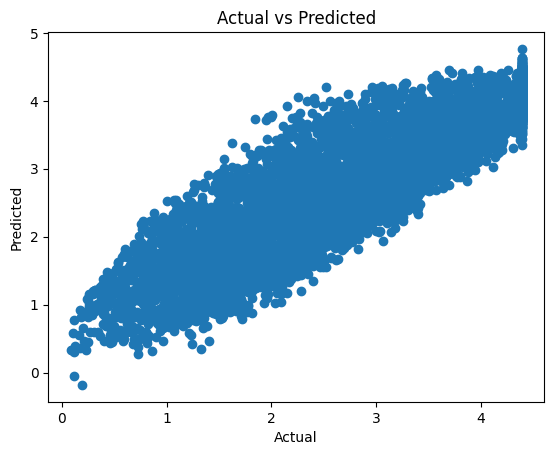

In [68]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [69]:
import joblib
# 5. save the file
from google.colab import drive
import os

# Mount the drive
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/ML_CCP/'
if not os.path.exists(save_path):
    os.makedirs(save_path)

# Save the model there
model.save(save_path + "revenue_model.keras")
print(f"Model saved to shared Drive: {save_path}")

# Save model
model.save(save_path + "revenue_model.keras")

# Save scaler
joblib.dump(scaler, save_path + "scaler.pkl")

# Save feature names
joblib.dump(X.columns.tolist(), save_path + "columns.pkl")

print("Everything saved successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved to shared Drive: /content/drive/MyDrive/ML_CCP/
Everything saved successfully!


### **Sherlock Function**

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Anomalies detected: 911

Sample Predictions with Bounds:

         actual  predicted  lower_bound  upper_bound
2308   2.691921   1.873647     1.561683     2.185611
22404  4.387201   4.437849     4.125885     4.749813
23397  2.428336   1.941468     1.629505     2.253432
25058  4.387201   4.318442     4.006478     4.630406
2664   3.772071   2.920571     2.608607     3.232535

Summary:
Min Lower Bound: -0.49279946088790894
Max Upper Bound: 5.075156211853027
Mean Prediction: 1.8580452
Std Deviation (Uncertainty): 0.0677626


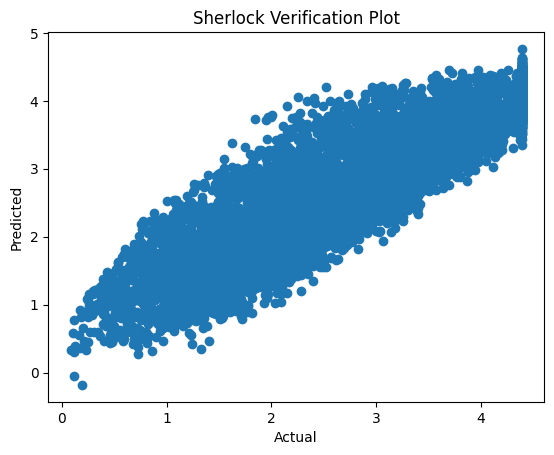

In [70]:
#extract predictions
y_pred = model.predict(X_test).flatten()
#sherlock
sherlock_df = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred
})

sherlock_df["error"] = abs(sherlock_df["actual"] - sherlock_df["predicted"])

threshold = sherlock_df["error"].mean() + sherlock_df["error"].std()

sherlock_df["anomaly"] = sherlock_df["error"] > threshold

print("Anomalies detected:", sherlock_df["anomaly"].sum())
#LOWER & UPPER BOUND
def add_bounds(df, k=1):
    """Adds prediction lower and upper bounds using error std deviation.
    k controls width of interval. """
    std_err = df["error"].std()

    df["lower_bound"] = df["predicted"] - (k * std_err)
    df["upper_bound"] = df["predicted"] + (k * std_err)

    return df


sherlock_df = add_bounds(sherlock_df, k=1)
print("\nSample Predictions with Bounds:\n")
print(sherlock_df[["actual", "predicted", "lower_bound", "upper_bound"]].head())

print("\nSummary:")
print("Min Lower Bound:", sherlock_df["lower_bound"].min())
print("Max Upper Bound:", sherlock_df["upper_bound"].max())

#Stability Check
def stability_check(model, x, noise_level=0.05, samples=50):
    preds = []

    for _ in range(samples):
        noise = np.random.normal(0, noise_level, x.shape)
        x_new = x.values + noise # Convert Series to numpy array before adding noise
        pred = model.predict(x_new.reshape(1, -1), verbose=0)[0][0]
        preds.append(pred)

    return np.mean(preds), np.std(preds)

mean_pred, std_pred = stability_check(model, X_test.iloc[0])

print("Mean Prediction:", mean_pred)
print("Std Deviation (Uncertainty):", std_pred)
#Visualization
plt.scatter(sherlock_df["actual"], sherlock_df["predicted"])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Sherlock Verification Plot")
plt.show()